# **Ejemplo básico de una red neuronal para clasificación de imágenes de Ropa**


## **1.Importación de las librerías**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

## **2.Carga de los Datos**
Vamos a utilizar el propio dataset que viene precargado en Keras:
https://keras.io/api/datasets/fashion_mnist/

In [3]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

'''class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']'''
               
class_names = ['Camiseta/top', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
'Sandalias', 'Camisa', 'Zapatillas deportivas', 'Bolso', 'Botines']  

4422102/4422102 [==============================] - 0s 0us/step


## **3.Exploración, Visualización de los Datos y Preprocesamiento**

Utilizamos len, shape, e imshow para explorar y ver con qué estamos trabajando.

In [4]:
train_images.shape

(60000, 28, 28)

In [5]:
len(train_labels)

60000

In [6]:
train_labels[0:5]

array([9, 0, 0, 3, 0], dtype=uint8)

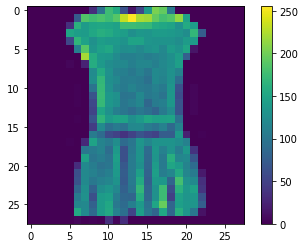

In [10]:
plt.figure()
plt.imshow(train_images[3])
plt.colorbar()


In [11]:
#comprobamos el tipo de prenda, nos devolverá un valor 0-9. Podemos usarlo para buscar
#en la lista de class_names para ver el nombre de la prenda
train_labels[0]


9

In [12]:
#comprobamos el nombre de la prenda
class_names [train_labels[0]]

'Botines'

**Vamos a escalar los valores de entrada en el rango 0-1**

In [13]:
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

train_images = train_images / 255.0
test_images = test_images / 255.0

In [14]:
print(f"train_images.shape: {train_images.shape}")
print(f"len(train_labels): {len(train_labels)}")
print(f"test_images.shape: {test_images.shape}")
print(f"len(test_labels): {len(test_labels)}")

train_images.shape: (60000, 28, 28)
len(train_labels): 60000
test_images.shape: (10000, 28, 28)
len(test_labels): 10000


**Vamos a mostrar varias prendas con sus nombres**

<function matplotlib.pyplot.show(close=None, block=None)>

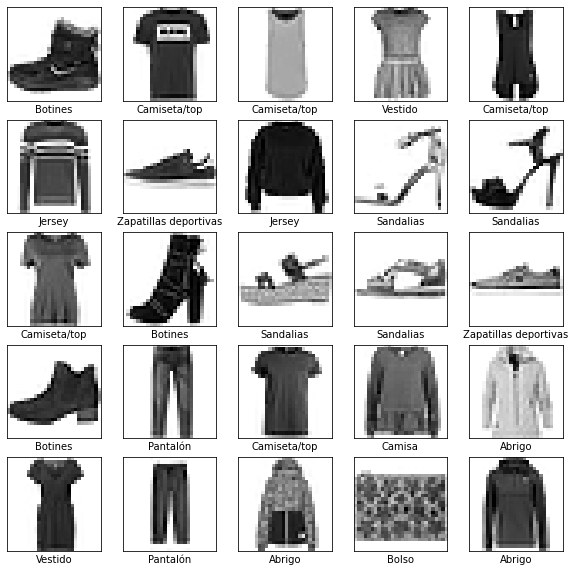

In [15]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(train_images[i], cmap = plt.cm.binary)
  plt.xlabel(class_names[train_labels[i]])

# El método show no es necesario en colab
plt.show

## **4.Construcción del Modelo - Creación de la Red Neuronal**

Llamamos a la clase Sequential y usamos layers para crear las capas. Con Dense, se crean las capas de red neuronal. Utilizaremos las funciones de activación sigmoid en las capas internas y Softmax en la de salida.

En el ejemplo anterior hemos preprocesado los datos de entrada con la función np.reshape(). Keras nos facilita este paso de reconvertir las muestras de entrada de 28x28 a un vector de 784 números con el **uso de la capa Flatten()**

**Flatten crea una capa que reduce a 1 la dimensión del array de las imágenes**

In [16]:
model = keras.Sequential([
   keras.layers.Flatten(input_shape = (28,28)),
   keras.layers.Dense(10, activation='relu'),
   keras.layers.Dense(10,activation='softmax')                       
])


Podemos comprobar con el método summary() que esta capa no requiere parámetros para aplicar la transformación (columna Param #). 

En general, **siempre usaremos esta capa del modelo para hacer esta operación en lugar de redimiensionar el tensor de datos antes de la entrada.**

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 10)                7850      
                                                                 
 dense_1 (Dense)             (None, 10)                110       
                                                                 
Total params: 7,960
Trainable params: 7,960
Non-trainable params: 0
_________________________________________________________________


## **5.Entrenamiento del Modelo**
El método compile nos permite configurar el optimizador, función de coste,etc. En este caso, vamos a recurrir al optimizador Adam, y la función de coste sparse_categorical_crossentropy.

In [18]:
model.compile(optimizer= 'sgd', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

## **6.Entrenamiento del Modelo**
Utilizamos la función fit para el entrenamiento de la DNN. Tenemos que pasar como argumentos los valores de entrada, los de salida (las etiquetas) y el número de iteraciones o epochs.

In [19]:
model.fit(train_images,train_labels,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 5s 2ms/step - loss: 1.0260 - accuracy: 0.6597
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.6112 - accuracy: 0.7906
Epoch 3/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.5449 - accuracy: 0.8138
Epoch 4/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5113 - accuracy: 0.8252
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.4910 - accuracy: 0.8315


## **7.Evaluación del modelo**
Para evaluar el modelo, recurrimos a la función evaluate y guardamos los valores que nos devuelve, el error o loss, y la precisión o accuracy.

In [20]:
test_loss,test_acc = model.evaluate(test_images,test_labels)

print('Test loss: ', test_loss)
print('Test accuracy: ', test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.5203 - accuracy: 0.8194
Test loss:  0.5203311443328857
Test accuracy:  0.8194000124931335


## **8.Generación del Modelo Predictivo y Pruebas**

Con la función predict, generamos la colección de resultados del modelo para nuevos datos de entrada, y podemos analizar su comportamiento.

In [21]:
predictions = model.predict(test_images)

313/313 [==============================] - 1s 1ms/step


In [22]:
print(predictions[5])

[9.96495713e-04 9.83308613e-01 6.92284550e-04 4.57249320e-04
 1.45272035e-02 2.74314876e-10 1.03302082e-05 5.73344305e-09
 7.78141202e-06 7.31197672e-11]


In [23]:
np.argmax(predictions[5])

1

In [24]:
class_names[1]

'Pantalón'

In [25]:
class_names[test_labels[5]]

'Pantalón'

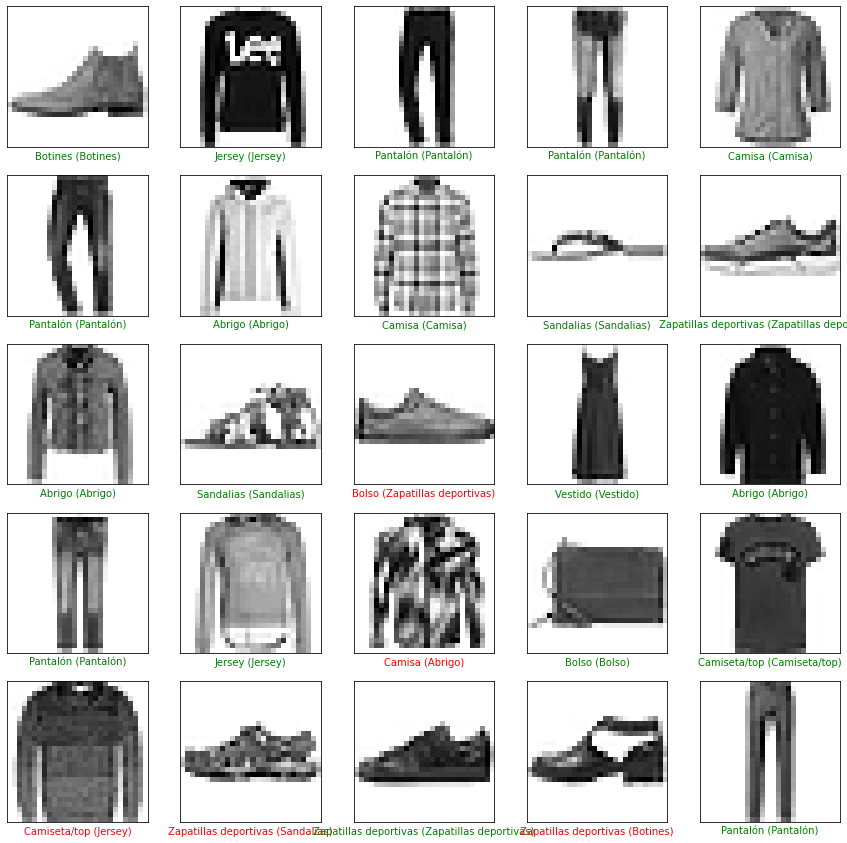

In [26]:
plt.figure(figsize=(15,15))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(test_images[i],cmap=plt.cm.binary)
  predicted_label = np.argmax(predictions[i])
  true_label = test_labels[i]
  if predicted_label == true_label:
    color = 'green'
  else:
    color = 'red'
  
  plt.xlabel("{} ({})".format(class_names[predicted_label],
                              class_names[true_label]),
                              color=color)

## **Puedes mejorar la precisión del modelo???** 💪💪💪💪